<a href="https://colab.research.google.com/github/megluc/COMP329-gamereview/blob/main/LSTM_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install kagglehub

import kagglehub
import os
import re
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [17]:
path = kagglehub.dataset_download("arashnic/game-review-dataset")
print("Dataset path:", path)

Using Colab cache for faster access to the 'game-review-dataset' dataset.
Dataset path: /kaggle/input/game-review-dataset


In [18]:
print(os.listdir(path))

['test_gr', 'train_gr']


In [19]:
import os

train_path = os.path.join(path, "train_gr")
print(os.listdir(train_path))

['game_overview.csv', 'train.csv']


In [20]:
import pandas as pd

file_name = None

for f in os.listdir(train_path):
    if f.endswith(".csv"):
        file_name = f
        print("Found CSV:", f)

df = pd.read_csv(os.path.join(train_path, file_name))
df.head()

Found CSV: game_overview.csv
Found CSV: train.csv


,review_id,title,year,user_review,user_suggestion
0,1,Spooky's Jump Scare Mansion,2016.0,I'm scared and hearing creepy voices. So I'll...,1
1,2,Spooky's Jump Scare Mansion,2016.0,"Best game, more better than Sam Pepper's YouTu...",1
2,3,Spooky's Jump Scare Mansion,2016.0,"A littly iffy on the controls, but once you kn...",1
3,4,Spooky's Jump Scare Mansion,2015.0,"Great game, fun and colorful and all that.A si...",1
4,5,Spooky's Jump Scare Mansion,2015.0,Not many games have the cute tag right next to...,1


In [21]:
test_path = os.path.join(path, "test_gr")

file_name = None
for f in os.listdir(test_path):
    if f.endswith(".csv"):
        file_name = f
        print("Found test CSV:", f)

test_df = pd.read_csv(os.path.join(test_path, file_name))
test_df.head()

Found test CSV: test.csv


,review_id,title,year,user_review
0,1603,Counter-Strike: Global Offensive,2015.0,"Nice graphics, new maps, weapons and models. B..."
1,1604,Counter-Strike: Global Offensive,2018.0,I would not recommend getting into this at its...
2,1605,Counter-Strike: Global Offensive,2018.0,Edit 11/12/18I have tried playing CS:GO recent...
3,1606,Counter-Strike: Global Offensive,2015.0,The game is great. But the community is the wo...
4,1607,Counter-Strike: Global Offensive,2015.0,I thank TrulyRazor for buying this for me a lo...


In [22]:
df = df[['user_review', 'user_suggestion']].dropna()

In [23]:
df = df.rename(columns={
    'user_review': 'review_text',
    'user_suggestion': 'recommended'
})

In [24]:
print(df['recommended'].value_counts())

recommended
1    9968
0    7526
Name: count, dtype: int64


In [25]:
df['recommended'] = df['recommended'].astype(int)

In [26]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df = df[['review_text', 'recommended']].dropna()
df['review_text'] = df['review_text'].apply(clean_text)
df['recommended'] = df['recommended'].astype(int)

In [27]:
X = df['review_text']
y = df['recommended']

# 80% train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 10% val + 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(len(X_train), len(X_val), len(X_test))

13995 1749 1750


In [28]:
MAX_VOCAB = 20000
MAX_LEN = 150

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input

# Define model
model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(input_dim=MAX_VOCAB, output_dim=128),

    LSTM(64, dropout=0.2, recurrent_dropout=0.2),

    Dropout(0.4),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

# Compile model (important before summary)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show parameter table
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,521 (9.96 MB)

 Trainable params: 2,611,521 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
)

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 236s 519ms/step - accuracy: 0.5744 - loss: 0.6817 - val_accuracy: 0.4683 - val_loss: 0.6904
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 226s 516ms/step - accuracy: 0.6219 - loss: 0.6400 - val_accuracy: 0.6209 - val_loss: 0.6425
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 233s 531ms/step - accuracy: 0.6542 - loss: 0.5939 - val_accuracy: 0.6335 - val_loss: 0.6438
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 230s 525ms/step - accuracy: 0.6745 - loss: 0.5535 - val_accuracy: 0.7844 - val_loss: 0.5705
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 231s 527ms/step - accuracy: 0.7937 - loss: 0.4637 - val_accuracy: 0.8022 - val_loss: 0.5280
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 228s 520ms/step - accuracy: 0.8609 - loss: 0.3437 - val_accuracy: 0.8210 - val_loss: 0.4507
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 227s 517ms/step - accuracy: 0.9125 - loss: 0.2510 - val_accuracy: 0.8359 - val_loss: 0.4787
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 257s 505ms/step - accuracy: 0.9378 -

In [31]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

print("LSTM model evaluation \n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("Classification Report")
print(classification_report(y_test, y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step
LSTM model evaluation 

Accuracy: 0.8091428571428572
Precision: 0.8190567853705486
Recall: 0.8535606820461384
F1 Score: 0.8359528487229863
Classification Report
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       753
           1       0.82      0.85      0.84       997

    accuracy                           0.81      1750
   macro avg       0.81      0.80      0.80      1750
weighted avg       0.81      0.81      0.81      1750

Confusion Matrix
[[565 188]
 [146 851]]


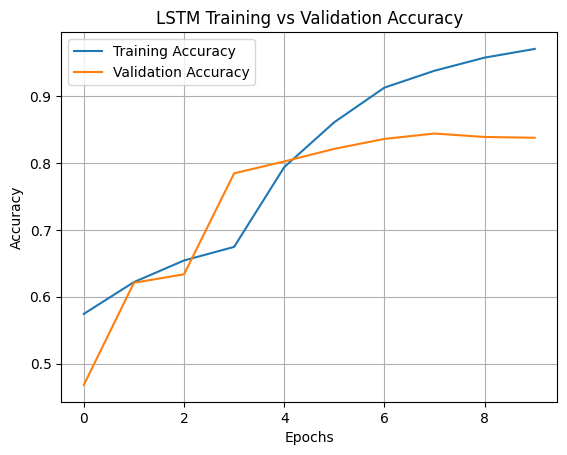

In [32]:

import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()